# Credit Card Default Risk — End-to-End Analysis

**Project:** CodeAlpha Data Science Internship — Finance Domain
**Dataset:** Credit Card Customer Default Dataset (10,000 customers)
**Goal:** Understand what drives customer default and build a simple, interpretable model to predict it.

---

### Dataset columns
| Column | Description |
|---|---|
| `default` | Target — did the customer default? (Yes/No) |
| `student` | Is the customer a student? (Yes/No) |
| `balance` | Average credit card balance ($) |
| `income` | Annual income ($) |

This notebook walks through the project in 5 stages: **Data Cleaning → EDA → Modeling → Insights → Conclusions**.


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from data_cleaning import load_data, clean_data, data_summary
from eda import summary_statistics, correlation_matrix, class_balance, group_means, generate_insights
from visualization import generate_all_plots
from model import run_full_pipeline

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 1. Data Understanding + Cleaning

In [2]:
raw_df = load_data('../data/Default.xlsx')
raw_df.head()


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Unnamed: 0,default,student,balance,income
0,1,No,No,729.53,"44,361.63"
1,2,No,Yes,817.18,"12,106.13"
2,3,No,No,"1,073.55","31,767.14"
3,4,No,No,529.25,"35,704.49"
4,5,No,No,785.66,"38,463.50"


In [3]:
print("Shape:", raw_df.shape)
print()
print(raw_df.dtypes)


Shape: (10000, 5)

Unnamed: 0      int64
default           str
student           str
balance       float64
income        float64
dtype: object


**Cleaning steps applied** (see `src/data_cleaning.py`):
1. Drop the redundant `Unnamed: 0` index column.
2. Check for missing values (none found in this dataset).
3. Check for and remove duplicate rows (none found).
4. Cast `default`/`student` to categorical, `balance`/`income` to float.
5. Create numeric `default_flag` / `student_flag` columns (0/1) for modeling.


In [4]:
df = clean_data(raw_df)
print(data_summary(raw_df, df))
df.head()


Raw shape:      (10000, 5)
Cleaned shape:  (10000, 6)
Missing values (raw):   0
Missing values (clean): 0
Duplicate rows removed: 0
Default rate: 3.33%


,default,student,balance,income,default_flag,student_flag
0,No,No,729.53,"44,361.63",0,0
1,No,Yes,817.18,"12,106.13",0,1
2,No,No,"1,073.55","31,767.14",0,0
3,No,No,529.25,"35,704.49",0,0
4,No,No,785.66,"38,463.50",0,0


## 2. Exploratory Data Analysis

### 2.1 Summary statistics

In [5]:
summary_statistics(df)

,balance,income
count,"10,000.00","10,000.00"
mean,835.37,"33,516.98"
std,483.71,"13,336.64"
min,0.00,771.97
25%,481.73,"21,340.46"
50%,823.64,"34,552.64"
75%,"1,166.31","43,807.73"
max,"2,654.32","73,554.23"


### 2.2 Class balance — how rare is default?

In [6]:
class_balance(df)

,count,percent
default,,
No,9667,96.67
Yes,333,3.33


Only **3.33%** of customers defaulted. This is a strongly **imbalanced classification problem** —
important to keep in mind: a model that always predicts "No" would already score ~96.7% accuracy
while being completely useless. We'll need precision/recall/ROC-AUC, not just accuracy.

### 2.3 Correlation analysis

In [7]:
correlation_matrix(df)

,default_flag,student_flag,balance,income
default_flag,1.00,0.04,0.35,-0.02
student_flag,0.04,1.00,0.20,-0.75
balance,0.35,0.20,1.00,-0.15
income,-0.02,-0.75,-0.15,1.00


### 2.4 Group comparisons

In [8]:
print("Mean balance/income by default status:")
display(group_means(df, 'default'))
print()
print("Mean balance/income by student status:")
display(group_means(df, 'student'))


Mean balance/income by default status:


,balance,income
default,,
No,803.94,"33,566.17"
Yes,"1,747.82","32,089.15"



Mean balance/income by student status:


,balance,income
student,,
No,771.77,"40,011.95"
Yes,987.82,"17,950.23"


### 2.5 Key visualizations

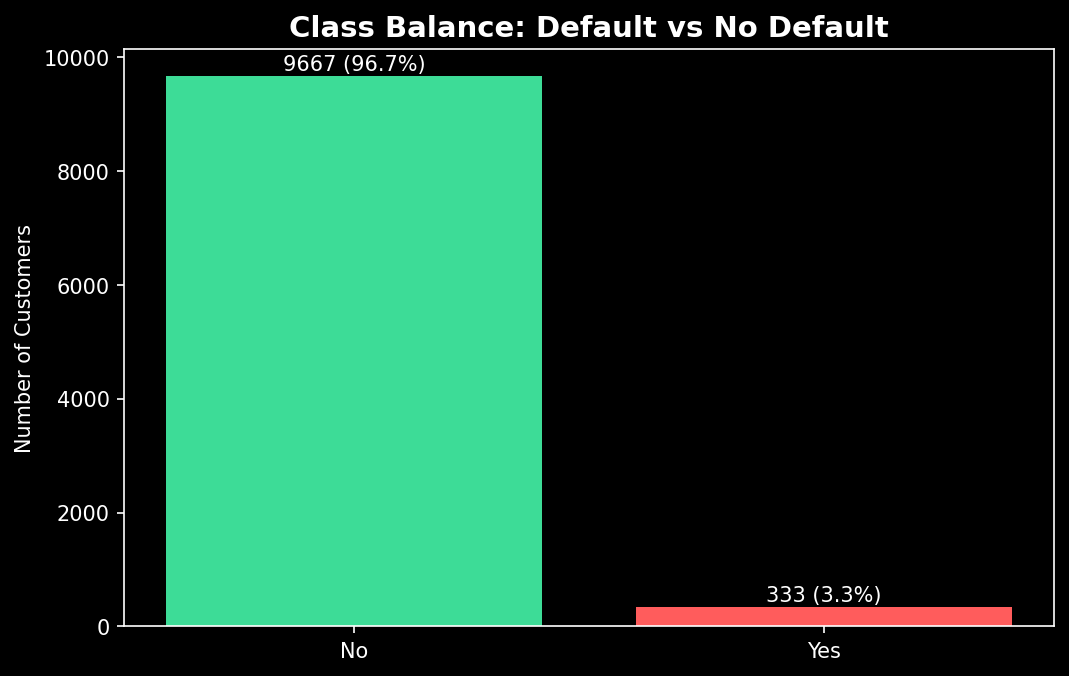

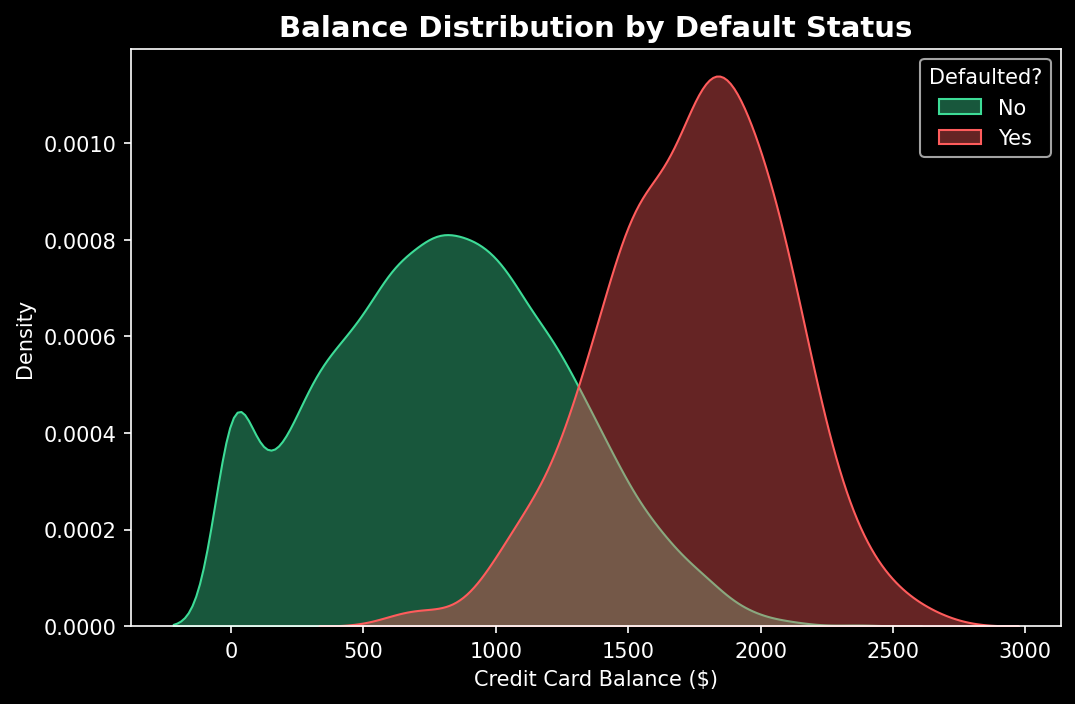

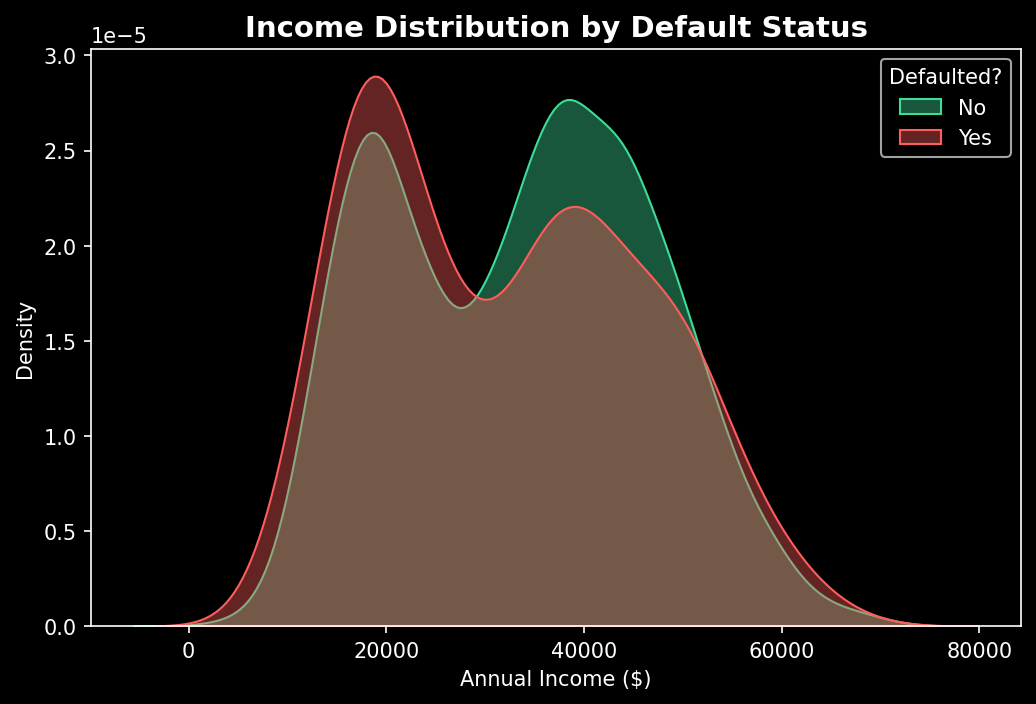

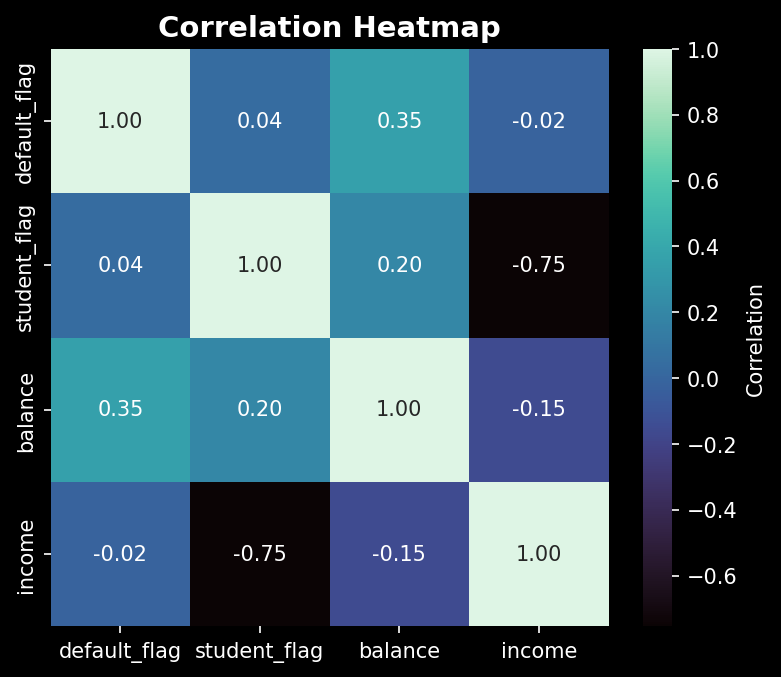

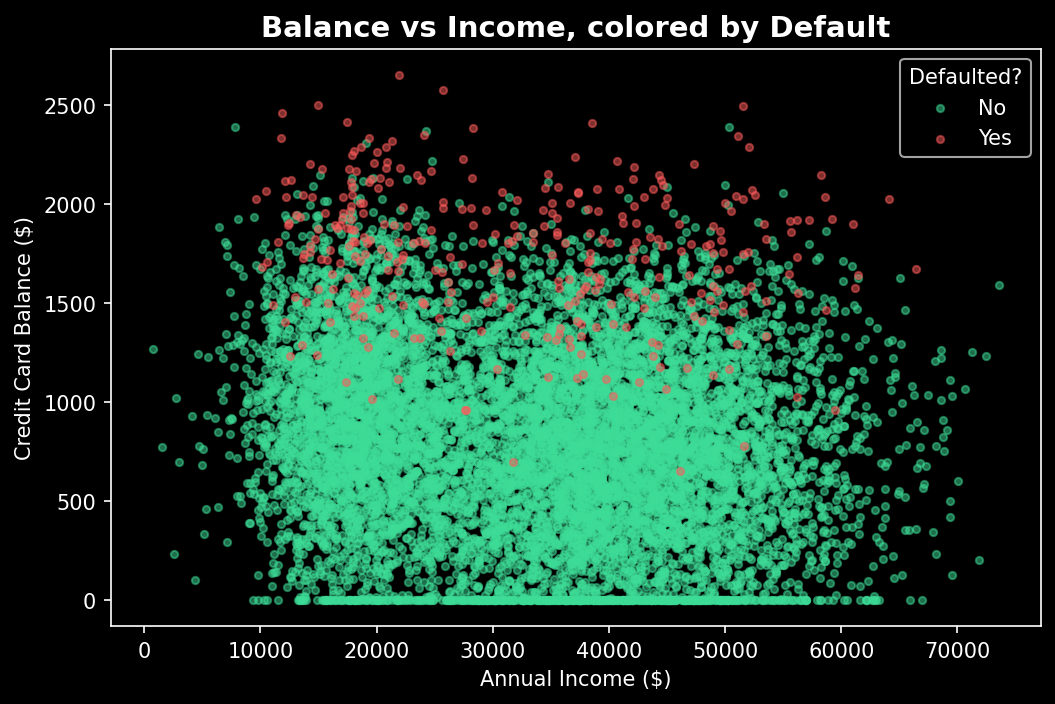

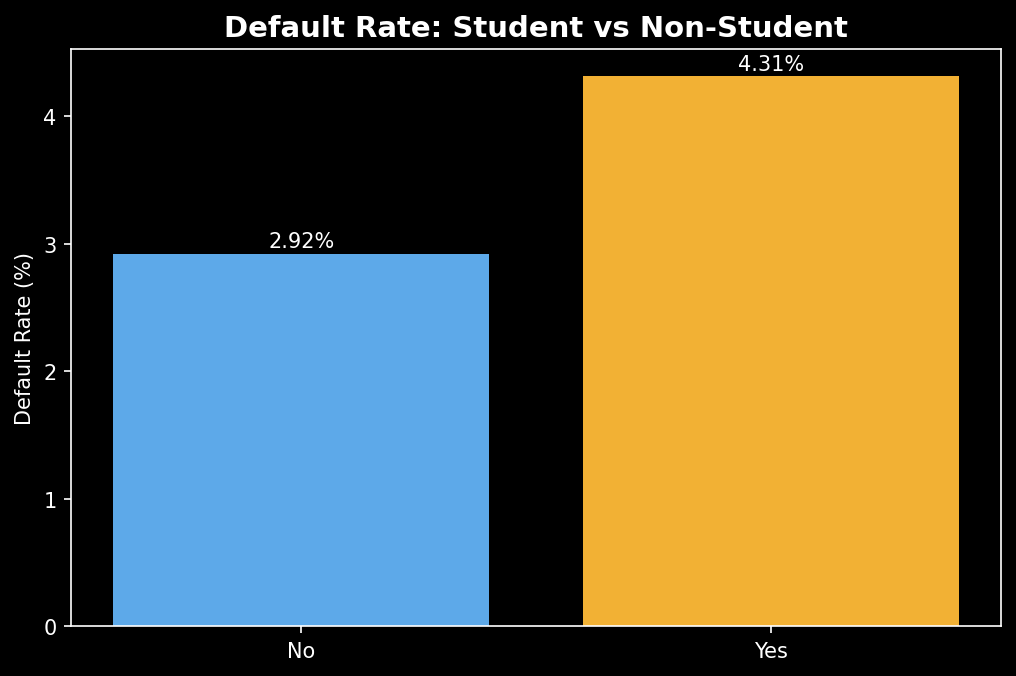

In [9]:
plot_paths = generate_all_plots(df, out_dir='../outputs/figures')
for p in plot_paths:
    display(Image(filename=p))


### 2.6 Automatically generated insights

In [10]:
for i, insight in enumerate(generate_insights(df), 1):
    print(f"{i}. {insight}\n")


1. Only 3.33% of customers defaulted -- this is a highly imbalanced classification problem, so accuracy alone will be a misleading metric (a model that always predicts 'No' would already be ~96.7% 'accurate').

2. Defaulters carry a much higher average balance ($1748) than non-defaulters ($804) -- balance is the single strongest behavioral signal of default risk in this dataset.

3. Average income is almost identical between defaulters ($32089) and non-defaulters ($33566) -- income alone is a weak predictor of default risk.

4. Students default at a higher raw rate (4.31%) than non-students (2.92%).

5. However, this is a confounding effect: students carry higher balances ($988 vs $772) but much lower income ($17950 vs $40012). So 'being a student' isn't directly risky -- it's a proxy for carrying a higher balance relative to income.

6. About 5.0% of customers carry a $0 balance (i.e. they don't revolve credit) -- these customers almost never default, and could be treated as a distinc

## 3. Machine Learning Model

**Model choice: Logistic Regression**
- The target is binary (default Yes/No) → classification problem.
- Logistic Regression is simple, fast, and — crucially for a finance use case —
  **interpretable**: each feature gets a clear coefficient a business stakeholder can read.
- We use `class_weight='balanced'` to counter the 3.33% vs 96.67% class imbalance,
  otherwise the model would just learn to always predict "No Default".

**Features used:** `balance`, `income`, `student_flag`
**Train/test split:** 80/20, stratified on the target so both sets keep the same default rate.


In [11]:
results = run_full_pipeline(df)
m = results['metrics']

print(f"Accuracy : {m['accuracy']:.2%}")
print(f"Precision: {m['precision']:.2%}")
print(f"Recall   : {m['recall']:.2%}")
print(f"F1 Score : {m['f1_score']:.2%}")
print(f"ROC-AUC  : {m['roc_auc']:.4f}")
print()
print(m['classification_report'])


Accuracy : 85.50%
Precision: 17.30%
Recall   : 88.06%
F1 Score : 28.92%
ROC-AUC  : 0.9487

              precision    recall  f1-score   support

           0       1.00      0.85      0.92      1933
           1       0.17      0.88      0.29        67

    accuracy                           0.85      2000
   macro avg       0.58      0.87      0.60      2000
weighted avg       0.97      0.85      0.90      2000



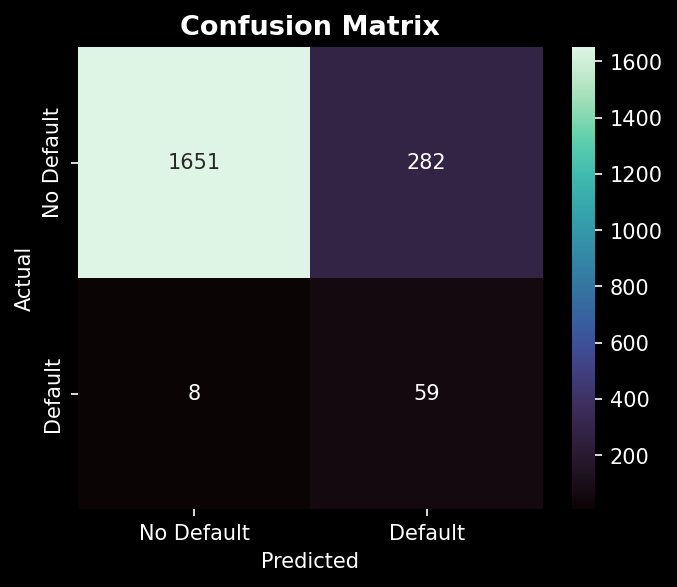

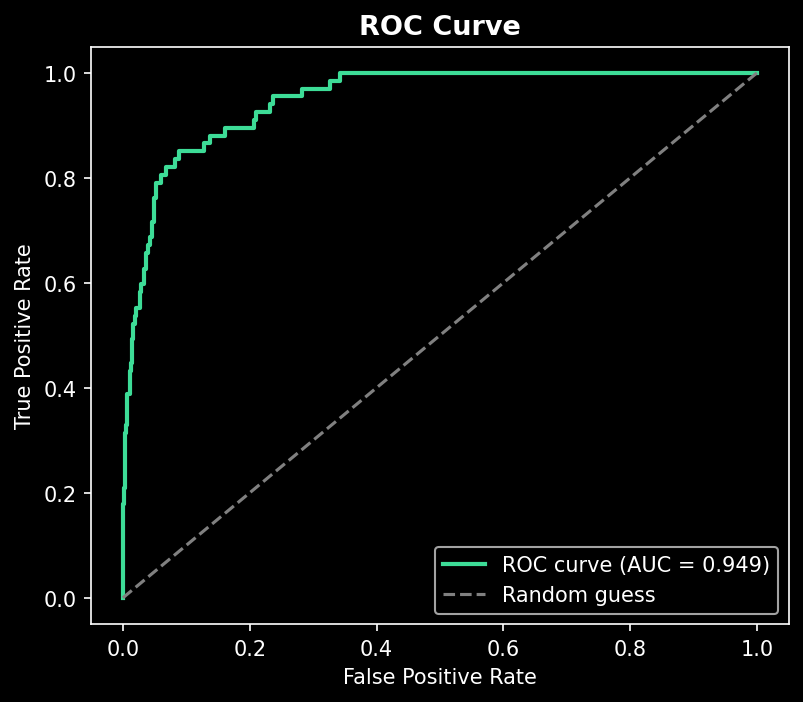

In [12]:
display(Image(filename=results['cm_path']))
display(Image(filename=results['roc_path']))


**Reading the confusion matrix:**
- **Recall (~88%)** matters most here: of all customers who actually defaulted, the model
  correctly flags ~88% of them. In credit risk, missing an actual defaulter is usually far
  more costly than a false alarm, so we prioritize recall over precision.
- **Precision is lower (~17%)** because the model casts a wide net — many flagged customers
  turn out fine. In practice this is fixed by treating the model's output as a *risk score*
  for manual review, not an automatic rejection.
- **ROC-AUC ≈ 0.95** is excellent — the model separates defaulters from non-defaulters very well.


In [13]:
results['importance']

,feature,coefficient
0,balance,2.77
2,student_flag,-0.30
1,income,-0.00


**Feature importance:** `balance` dominates the model by a wide margin — it has by far the
largest coefficient. `student_flag` has a small *negative* coefficient once balance and income
are controlled for, confirming the confounding pattern: students aren't inherently riskier,
they just tend to carry higher balances relative to their income.


## 4. Business Insights

1. **Balance is the #1 driver of default risk.** Customers who default carry, on average,
   more than double the balance of those who don't ($1,748 vs $804). Any early-warning
   system should weight balance heavily.
2. **Income alone is a weak signal.** Defaulters and non-defaulters have almost identical
   average income — income should not be used in isolation to assess risk.
3. **The student effect is a confound, not a cause.** Students show a higher raw default rate,
   but this disappears once balance and income are accounted for — they simply carry higher
   balances relative to lower income.
4. **A meaningful "zero-balance" segment exists.** ~5% of customers carry no revolving balance
   at all and almost never default — these could be treated as a distinct low-risk tier with
   reduced monitoring overhead.
5. **The dataset is highly imbalanced (3.33% default rate)**, which is realistic for credit
   portfolios but means accuracy is a misleading metric — recall and ROC-AUC tell the real story.
6. **The model achieves strong separation (ROC-AUC 0.95)** using just 3 simple features,
   showing that a lightweight, explainable model can already provide strong early-warning value
   without needing complex ML.
7. **Recommended business action:** flag customers whose balance crosses ~$1,800 (where defaults
   start clustering, see the balance-vs-income scatter plot) for proactive outreach or a credit
   limit review, rather than waiting for a missed payment.


## 5. Conclusion & Suggested Improvements

**Summary:** Using a simple Logistic Regression model on just `balance`, `income`, and
`student` status, we can identify ~88% of customers who go on to default, with a strong
ROC-AUC of ~0.95. Balance is by far the strongest predictor; income alone tells us little;
and the apparent "student risk" is actually explained by balance and income.

**Suggested improvements for a v2:**
- **Try other models** (Random Forest, Gradient Boosting / XGBoost) and compare ROC-AUC —
  may capture non-linear balance/income interactions Logistic Regression misses.
- **Threshold tuning**: instead of the default 0.5 cutoff, tune the probability threshold
  against a real cost matrix (cost of a missed default vs. cost of a false alarm).
- **More features**: this dataset only has 3 predictors — a real-world version would add
  payment history, credit utilization ratio, account age, and number of late payments.
- **Resampling techniques** (SMOTE) as an alternative/complement to `class_weight='balanced'`.
- **Calibrate probabilities** so the model's output can be used directly as a risk score
  (e.g. with `CalibratedClassifierCV`).
